In [1]:
import argparse
import copy
import json
import os.path
import random
import sys
import pandas as pd
import numpy as np
import torch
import pickle
import webdataset as wds
from data_utils import (
    alphabet,
    element_dict_rev,
    get_score,
    get_seq_rec,
    parse_PDB,
    restype_1to3,
    restype_int_to_str,
    restype_str_to_int,
    write_full_PDB,
    get_ssm_mutations,
    Mutation,
    get_nearest_neighbours
)
from model_utils import ProteinMPNN, nlcpl
from prody import writePDB
from sc_utils import Packer, pack_side_chains
import etab_utils
from tqdm import tqdm
from Bio.PDB import PDBParser
import matplotlib.pyplot as plt
import plotly.express as px
from prody import *
confProDy(verbosity="none")
import plotly.io as pio
pio.renderers.default = 'notebook'

In [2]:
%run 2025_05_06_ligandmpnn_utils.ipynb

/home/fosterb/localcolabfold/colabfold-conda/lib/python3.10/site-packages/webdataset/compat.py:389: UserWarning:

WebDataset(shardshuffle=...) is None; set explicitly to False or a number



In [310]:
## Set up arguments and load model

device = torch.device("cuda" if (torch.cuda.is_available()) else "cpu")
# device = "cpu"
model_type = 'ligand_mpnn'
model_checkpoint = 'ligand_mpnn'
use_potts = False
ligand_mpnn_use_side_chain_context = 0 # default 0
parse_atoms_with_zero_occupancy = 1 # default 0
transmembrane_buried = "" # default ""
transmembrane_interface = "" # default ""
ligand_mpnn_cutoff_for_score = 8 # default 8
ligand_mpnn_use_atom_context = 1 # default 1 for ligandmpnn
temperature = 0.1 # default 0.1
clone = True
node_self_sub = ""
updated_alist = False # default False (True for Potts versions)

checkpoint_path = checkpoints[model_checkpoint]
base_checkpoint = torch.load(checkpoints['ligand_mpnn'], map_location=device)
checkpoint = torch.load(checkpoint_path, map_location=device)
# if 'retrained' in model_checkpoint or 'potts' in model_checkpoint:
#     checkpoint['model_state_dict'] = {k[8:]: v for k,v in checkpoint['model_state_dict'].items()}
if model_type == "ligand_mpnn":
    atom_context_num = base_checkpoint["atom_context_num"]
    ligand_mpnn_use_side_chain_context = ligand_mpnn_use_side_chain_context
    k_neighbors = base_checkpoint["num_edges"]
else:
    atom_context_num = 1
    ligand_mpnn_use_side_chain_context = 0
    k_neighbors = checkpoint["num_edges"]
    
model = ProteinMPNN(
    node_features=128,
    edge_features=128,
    hidden_dim=128,
    num_encoder_layers=3,
    num_decoder_layers=3,
    k_neighbors=k_neighbors,
    device=device,
    atom_context_num=atom_context_num,
    model_type=model_type,
    ligand_mpnn_use_side_chain_context=ligand_mpnn_use_side_chain_context,
    use_potts=use_potts,
    clone=clone,
    node_self_sub=node_self_sub,
    for_energy=True,
    updated_alist=updated_alist
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model = model.eval()


datasets_to_run = {
    'megascale': False,
    'megascale_double': False,
    'megascale_double_mean': False,
    'fireprot': False,
    'covid': False,
    'covid_stability': False,
    'covid_split': False,
    'protabank': False,
    'ppb': False,
    'bcl2': False,
    'S669': False,
    'Sun': False,
    'prem': False,
    'cdc28': False,
    'cdc28_atp': False,
    'cdc28_ligand': False,
    'cdc28_only': False,
    'swe1_atp': True,
    'swe1_ligand': True,
    'swe1_only': True,
}

compare_to_exp = True
singlechain = False
ablate_seq = False
ablate_struct = False
ablate_nodes = False
ablate_edges = False
ablate_struct_layers = False
use_sum = True
ablate_type = "zero"
ener_fn = etab_utils.stability_loss_loop_ddg
model_name = model_checkpoint #'ligand_mpnn'
run_name = 'default'
ener_calc = 'ddG'
use_potts = False


In [311]:
for dataset_name, dataset_settings in all_dataset_settings.items():
    if not datasets_to_run[dataset_name]: continue
    print(f"Analyzing {dataset_name}")
    if 'three_plus_chains' in dataset_settings.keys():
        three_plus_chains = dataset_settings['three_plus_chains']
    else:
        three_plus_chains = False
    print('here')
    test_df, pdbs, raw_data_dir, offset = dataset_settings['test_df'], dataset_settings['pdbs'], dataset_settings['raw_data_dir'], dataset_settings['offset']  
    
    all_refs, all_refs_mean, all_preds, all_preds_mean, pdb_stats_df, all_corrs, merge_dfs, pred_dfs, real_dfs = run_model(pdbs, raw_data_dir, compare_to_exp, test_df, singlechain, offset,
  model, use_potts, ablate_seq, ablate_struct, ablate_nodes, ablate_edges, ablate_struct_layers, ablate_type, ener_fn,
  model_name, run_name, dataset_name, three_plus_chains, model_type=model_type, device=device, updated_alist=updated_alist, ener_calc=ener_calc, parse_atoms_with_zero_occupancy=1, write_fasta=True)
    

Analyzing swe1_atp
here


  0%|          | 0/1 [00:00<?, ?it/s]

/mnt/shared/fosterb/Joel_phosphate/pdbs/swe1_atp.pdb B
/mnt/shared/fosterb/Joel_phosphate/pdbs/swe1_atp.pdb B


100%|██████████| 1/1 [00:19<00:00, 19.37s/it]


Analyzing swe1_ligand
here


  0%|          | 0/1 [00:00<?, ?it/s]

/mnt/shared/fosterb/Joel_phosphate/pdbs/swe1_ligand.pdb B
/mnt/shared/fosterb/Joel_phosphate/pdbs/swe1_ligand.pdb B


100%|██████████| 1/1 [00:19<00:00, 19.19s/it]


Analyzing swe1_only
here


100%|██████████| 1/1 [00:19<00:00, 19.13s/it]


In [313]:
def convert_pred_df(pred_path, final_path, use_potts):
    df_out = pd.read_csv(pred_path)
    df_final = {'mutation': [], 'ddG_pred': []}
    for wt, mut, pred in df_out[['wt', 'mut', 'pred']].values:
        for ipos, (wc, mc) in enumerate(zip(wt, mut)):
            if wc != mc:
                break
        df_final['mutation'].append(wc + str(ipos + 1) + mc)
        df_final['ddG_pred'].append(pred)
    df_final = pd.DataFrame(df_final)
    if not use_potts:
        df_final['ddG_pred'] *= -1
    df_final.to_csv(final_path)
    return df_final

prot = 'swe1'
pred_path_atp = f'/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/{model_name}/{model_name}-default-{prot}_atp.csv'
final_path_atp = f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_atp_v3.csv'
atp_df = convert_pred_df(pred_path_atp, final_path_atp, use_potts)
pred_path_ligand = f'/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/{model_name}/{model_name}-default-{prot}_ligand.csv'
final_path_ligand = f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_ligand_v3.csv'
ligand_df = convert_pred_df(pred_path_ligand, final_path_ligand, use_potts)
pred_path_only = f'/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/{model_name}/{model_name}-default-{prot}_only.csv'
final_path_only = f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_only_v3.csv'
only_df = convert_pred_df(pred_path_only, final_path_only, use_potts)
df_out = pd.read_csv(pred_path_atp)


In [315]:
merge_df = atp_df.merge(ligand_df, on='mutation')
merge_df['ddG_pred'] = merge_df['ddG_pred_y'] - merge_df['ddG_pred_x']
del merge_df['ddG_pred_x']
del merge_df['ddG_pred_y']
merge_df.to_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_diff_v3.csv')

In [296]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

AMINO_ACIDS = ['A','C','D','E','F','G','H','I','K','L',
               'M','N','P','Q','R','S','T','V','W','Y']

def make_dms_matrix(df, sequence, energy_col='ddG_pred'):
    """
    Convert a mutation dataframe with columns:
       - 'mutation' of form <wt><pos><mut>
       - energy_col (e.g., ddG_pred)
    into a 20 x L matrix for DMS plotting.
    Missing WT→WT values are filled with 0.
    """

    L = len(sequence)
    mat = np.zeros((20, L))  # initialize with WT=WT zeros

    # Parse mutation field
    for _, row in df.iterrows():
        mut = row['mutation']
        wt = mut[0]
        pos = int(mut[1:-1])  # 1-indexed
        aa = mut[-1]
        value = row[energy_col]

        # row index: mutant AA
        if aa not in AMINO_ACIDS:
            continue  # ignore unsupported mutants
        mut_idx = AMINO_ACIDS.index(aa)

        # col index: position
        col = pos - 1

        mat[mut_idx, col] = value

    return mat


def plot_dms(plot_data, sequence,
             title='COORDinator Protein Predictions',
             clabel='Predicted ddG (a.u.)',
             save_path=None,
             row_norm=False,
             figsize=(4, 4),
             all_norm=False,
             ener_type='ddG'):

    if all_norm:
        plot_data = (plot_data - np.nanmin(plot_data)) / np.nanmax(plot_data - np.nanmin(plot_data))
    elif row_norm:
        min_vals = np.nanmin(plot_data, axis=1, keepdims=True)
        max_vals = np.nanmax(plot_data, axis=1, keepdims=True)
        plot_data = (plot_data - min_vals) / (max_vals - min_vals)

    amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
                   'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

    # Define custom colors for the colormap
    blue = (0.0, 0.0, 1.0)    # RGB for blue
    gray90 = (0.9, 0.9, 0.9)  # RGB for gray90
    red = (1.0, 0.0, 0.0)     # RGB for red

    # Create a diverging colormap
    cmap = mcolors.LinearSegmentedColormap.from_list("Blue_Gray90_Red", [blue, gray90, red])

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sns.set(font_scale=0.6)
    if ener_type == 'ddG':
        center = 0
    else:
        center = np.nanmean(plot_data)
    sns.heatmap(
        plot_data,
        cmap=cmap,
        center=center,
        yticklabels=amino_acids,
        xticklabels=list(sequence),
        cbar_kws={'shrink': 0.8, 'pad': 0.02, 'label': clabel}  # Colorbar options
    )


    for tick in ax.get_yticklabels():
        tick.set_rotation(0)
        tick.set_ha('left')
        tick.set_position((-0.03, tick.get_position()[1]))  # Move labels to the left

    # Customize x-axis
    plt.xticks(rotation=0)
    plt.xlabel('WT Residue')
    plt.ylabel('Mutant Residue')

    # Add a title
    plt.title(title)

    if save_path is not None:
        plt.savefig(save_path, dpi=250)
    plt.show()

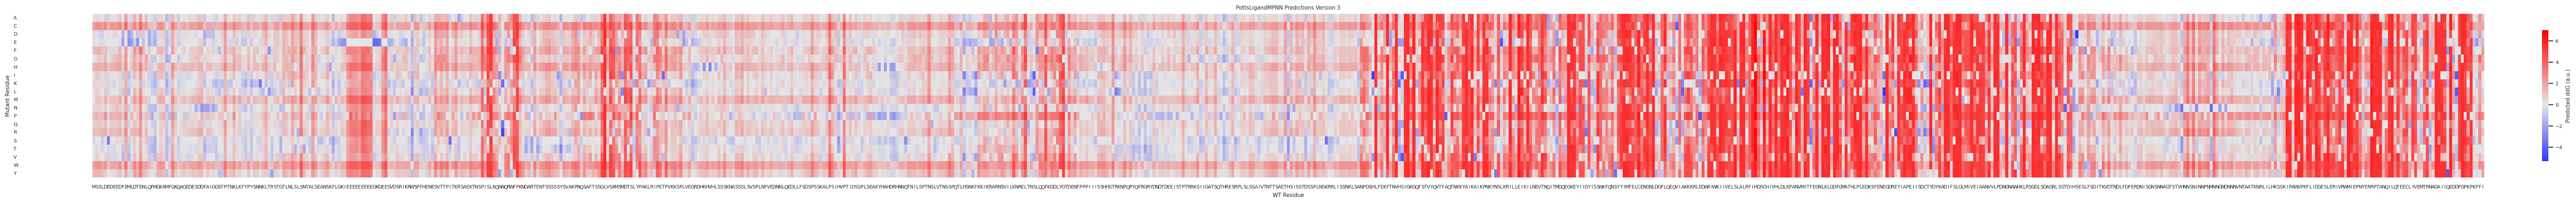

In [317]:
df = pd.read_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_atp_v3.csv')

dms_matrix = make_dms_matrix(df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 3', figsize=(70,4), save_path=f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_{prot}_atp_v3.png') #(25, 4)

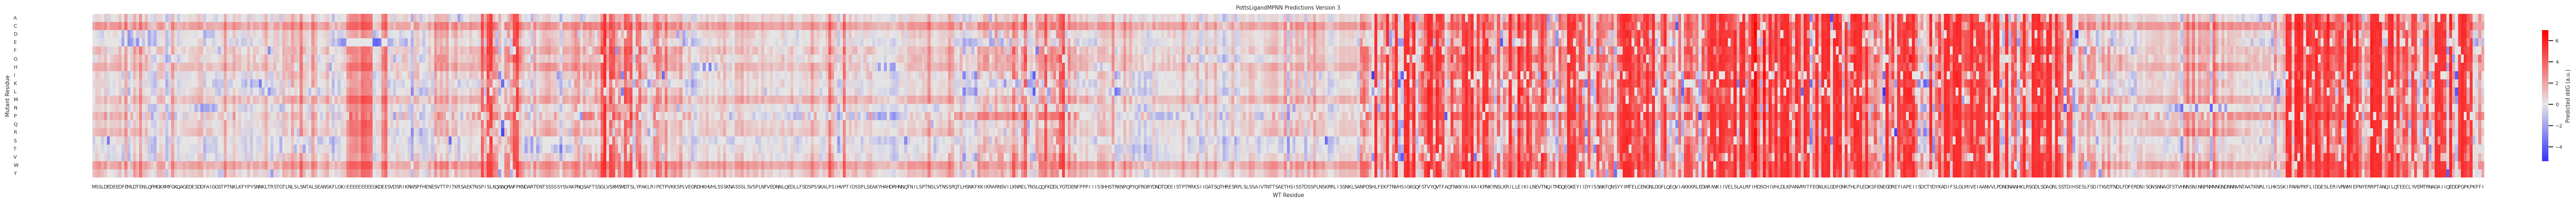

In [318]:
df = pd.read_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_ligand_v3.csv')

dms_matrix = make_dms_matrix(df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 3', figsize=(70,4), save_path=f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_{prot}_ligand_v3.png')

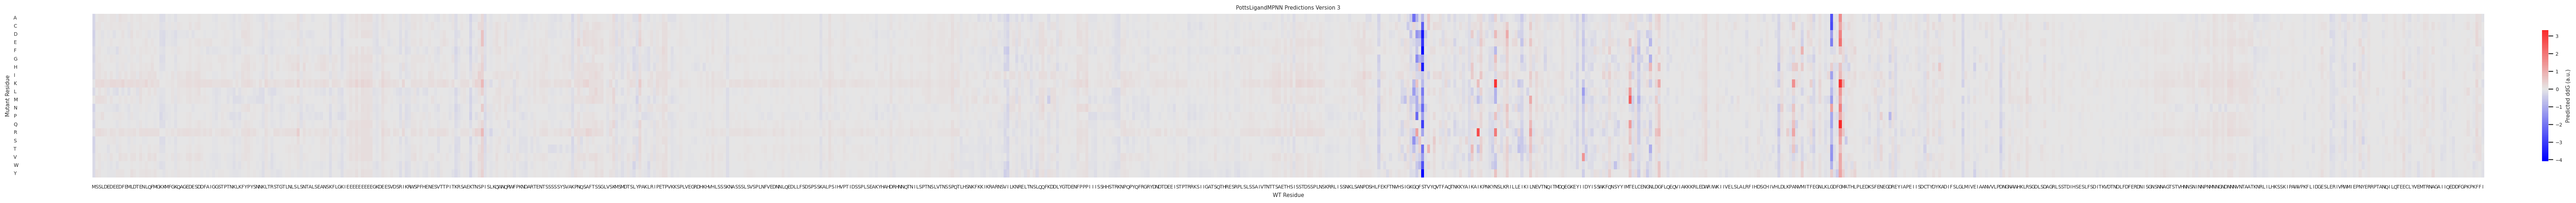

In [319]:
df = pd.read_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_diff_v3.csv')

dms_matrix = make_dms_matrix(df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 3', figsize=(70,4), save_path=f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_{prot}_diff_v3.png')

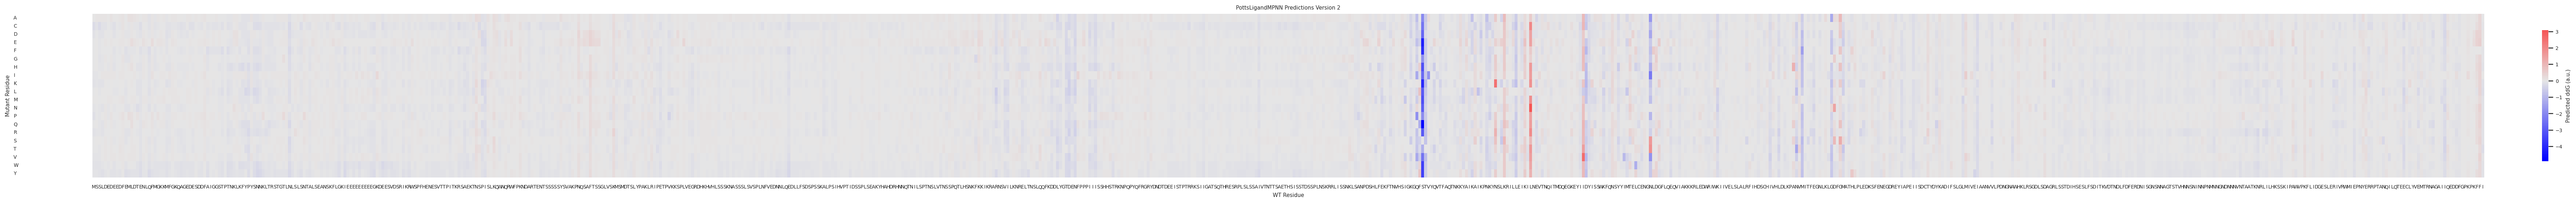

In [306]:
df = pd.read_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_diff_v2.csv')

dms_matrix = make_dms_matrix(df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 2', figsize=(70,4), save_path=f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_{prot}_diff_v2.png')

In [281]:
df = pd.read_csv('/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_cdc28_diff_v3.csv')

df['ddG_pred'].min(), df['ddG_pred'].max()

(-7.717830657958984, 4.741354703903198)

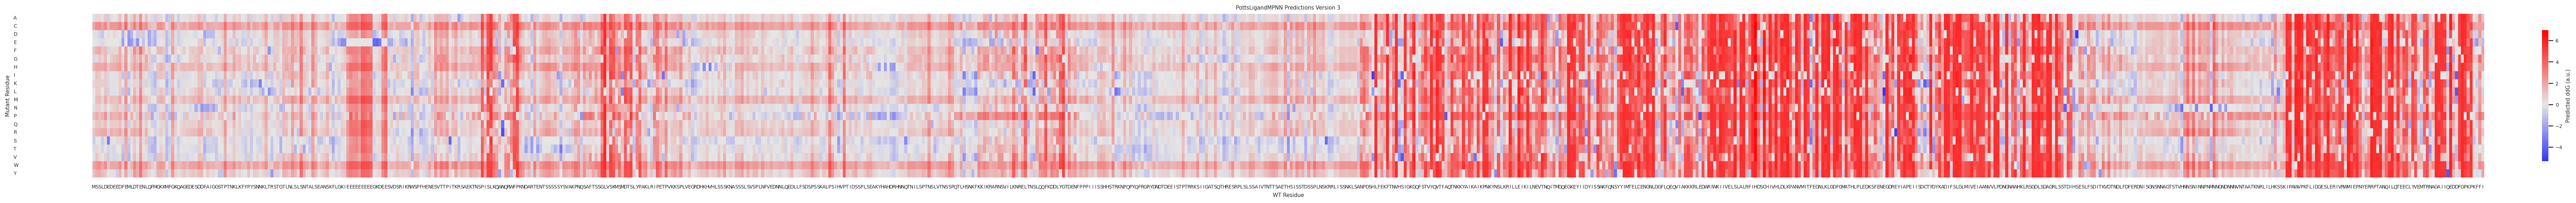

In [320]:
df = pd.read_csv(f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_{prot}_only_v3.csv')

dms_matrix = make_dms_matrix(df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 3', figsize=(70,4), save_path=f'/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_{prot}_only_v3.png')

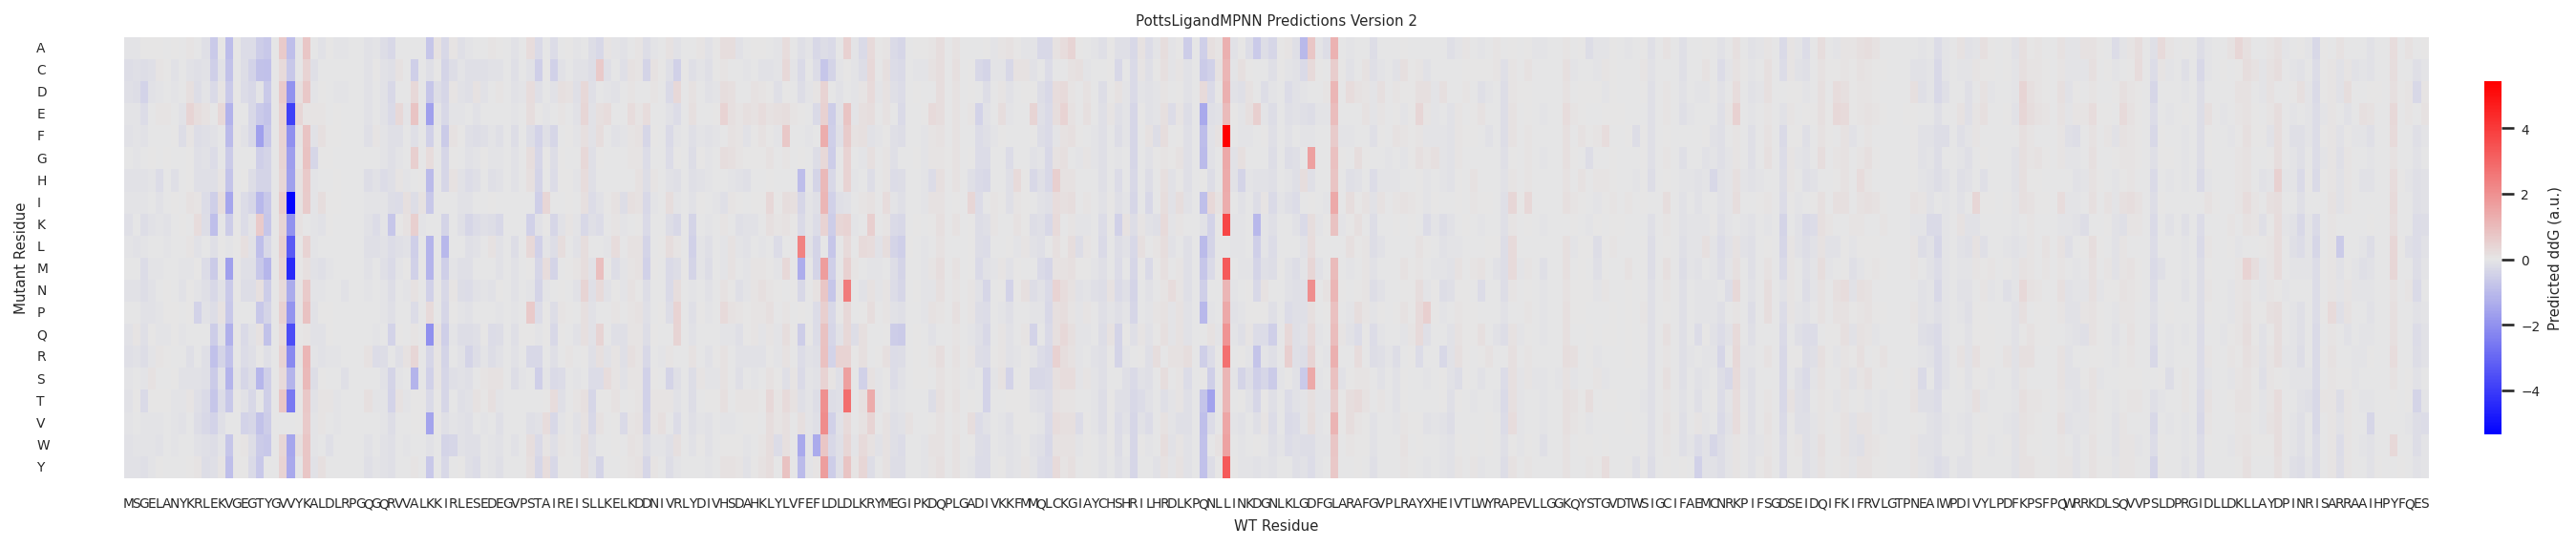

In [235]:
dms_matrix = make_dms_matrix(merge_df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 2', figsize=(25,4), save_path='/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_cdc28_diff_v2.png')

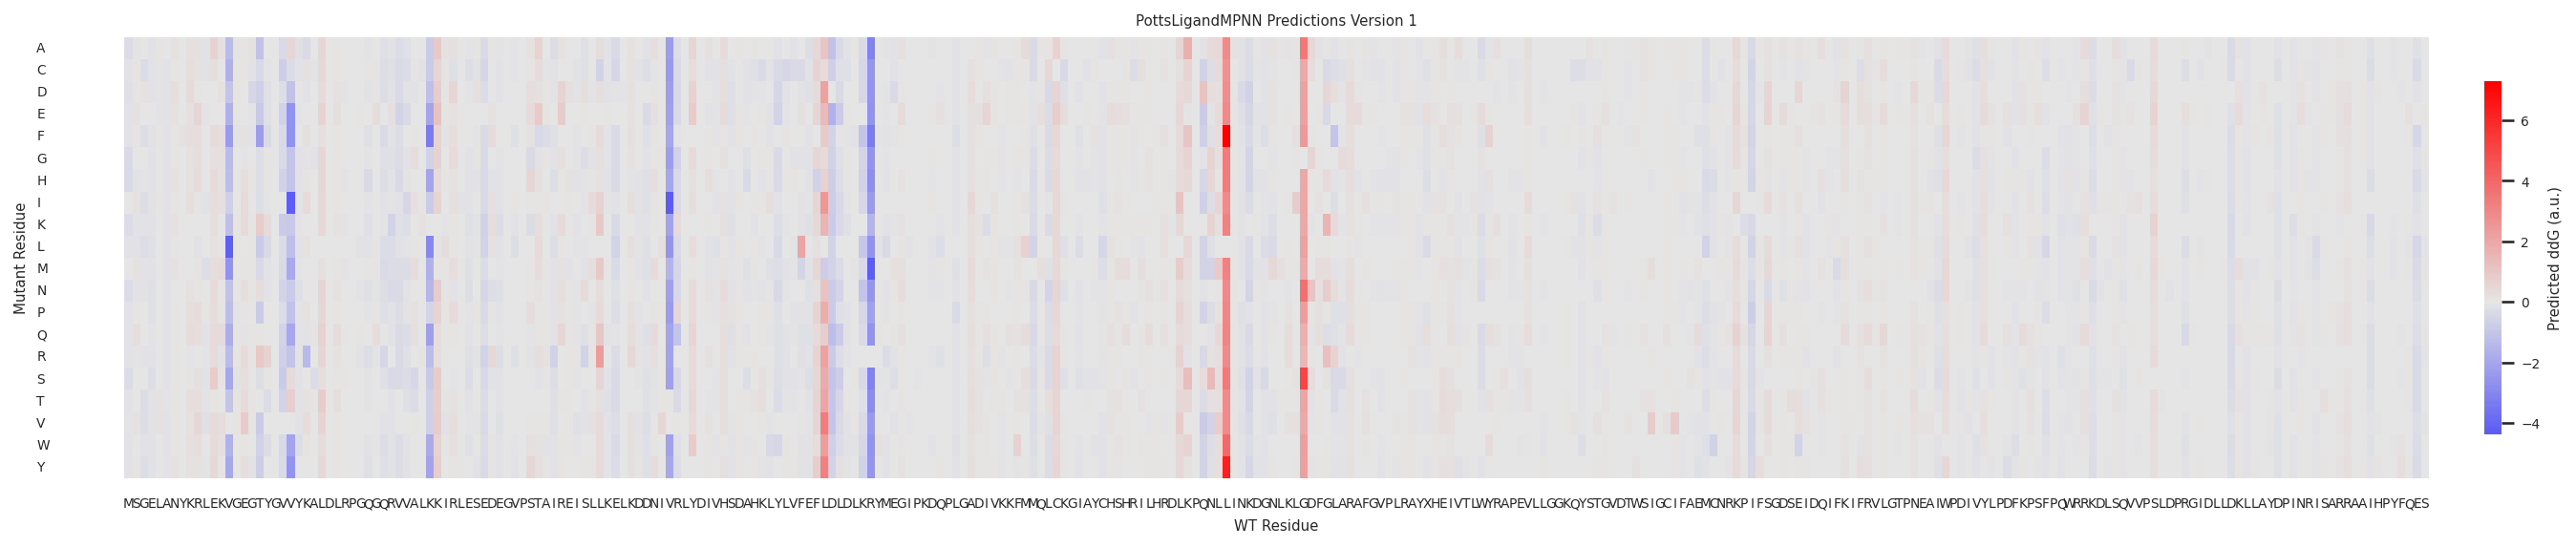

In [242]:
dms_matrix = make_dms_matrix(merge_df, df_out['wt'].values[0], energy_col='ddG_pred')
plot_dms(dms_matrix, df_out['wt'].values[0], title='PottsLigandMPNN Predictions Version 1', figsize=(25,4), save_path='/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_DMS_plot_cdc28_atp_v1.png')

In [221]:
df = pd.read_csv('/mnt/shared/fosterb/Joel_phosphate/PottsLigandMPNN_predictions_cdc28_atp_v1.csv')
if not use_potts:
    df['ddG_pred'] *= -1

,Unnamed: 0,mutation,ddG_pred
0,0,M1A,-0.194857
1,1,M1C,2.510518
2,2,M1D,0.522987
3,3,M1E,-0.232697
4,4,M1F,1.224480
...,...,...,...
5658,5658,S298R,-0.527664
5659,5659,S298T,0.560934
5660,5660,S298V,0.005521
5661,5661,S298W,2.185785


In [38]:
ener_calc, use_potts

('ddG', False)

In [40]:
for dataset_name, dataset_settings in all_dataset_settings.items():
    if not datasets_to_run[dataset_name]: continue
    print(f"Analyzing {dataset_name}")
    test_df, pdbs, raw_data_dir, offset = dataset_settings['test_df'], dataset_settings['pdbs'], dataset_settings['raw_data_dir'], dataset_settings['offset']
    pdb_stats_df = {'pdb': [], 'corr': [], 'nsr': [], 'nlll_loss': [], 'nlcpl_loss': [], 'n': []}
    pdbs = list(test_df['WT_name'].unique())
    new_dfs = []
    
    for pdb in tqdm(pdbs):
        pdb_id = pdb.split('.')[0]
        pdb_df = test_df[test_df['WT_name'] == pdb]
        chain_id = pdb_df['chain'].values[0]
        fasta_file = f'/home/fosterb/TERMinator-public_mirror/analysis/ener_inputs/{dataset_name}_{pdb_id}_{chain_id}.fasta'
        fasta_file2 = f'/home/fosterb/TERMinator-public_mirror/analysis/ener_inputs/{dataset_name}_{pdb_id}_{chain_id}.fasta2'
        if not os.path.exists(fasta_file):
            continue
        with open(fasta_file, 'r') as f:
            lines = f.readlines()
        with open(fasta_file2, 'w') as f:
            for label, seq in zip(lines[::2], lines[1::2]):
                int_seq = [int(c.strip()) for c in seq.strip().strip(']').strip('[').split(',')]
                seq = "".join(etab_utils.ints_to_seq(int_seq))
                f.write(label)
                f.write(seq + '\n')

Analyzing megascale


  0%|          | 0/28 [00:00<?, ?it/s]


ValueError: invalid literal for int() with base 10: 'EEEIEKWIETLLKRNISLRVNGKDLEIGSEEFKEWVEKFIKEV'

In [42]:
fasta_file

'/home/fosterb/TERMinator-public_mirror/analysis/ener_inputs/megascale_HEEH_KT_rd6_0746_A.fasta'

In [10]:
atoms = parsePDB('/mnt/shared/fosterb/S669_data/pdbs/4YEE.pdb')

In [11]:
prot_atoms = atoms.select("protein")

In [12]:
prot_atoms

<Selection: 'protein' from 4YEE (11966 atoms)>

In [13]:
# CA_atoms = atoms.select("name CA")
CA_atoms = atoms.select("occupancy > 0").select("protein").select("name CA")
CA_chain_ids = CA_atoms.getResnames()

In [14]:
for ca in CA_chain_ids:
    print(ca)
    break

ASP


In [23]:
test_seq = torch.tensor([ 2,  5,  0,  8,  7, 19,  0, 13,  1,  0,  5,  1,  6, 13, 13, 11,  5, 13,
         5,  7, 12,  5,  0,  4, 12, 12,  9,  0,  5,  6, 17,  0,  3,  7,  9,  0,
         8,  3,  5,  5, 14,  3, 19,  9,  7,  9, 17,  9,  9, 19,  5,  9, 13,  5,
        13,  7,  3, 17,  8,  5, 10,  8, 19, 11,  5, 17, 10, 15, 15,  4,  0, 13,
         9,  8,  2,  3,  3,  7,  0,  0, 17,  9, 11,  6,  7,  0, 16,  0, 18,  5,
         2,  0,  8,  8, 17,  8,  5,  4,  8, 12,  4, 16,  0,  3,  3, 17,  8,  8,
         9, 14,  0,  8,  8,  9, 16, 12, 13, 13, 17,  9,  0,  3, 14,  8,  8,  9,
         5,  9], device='cuda:0', dtype=torch.int32)
"".join(etab_utils.ints_to_seq_torch(test_seq))

'DGAKIYAQCAGCHQQNGQGIPGAFPPLAGHVAEILAKEGGREYLILVLLYGLQGQIEVKGMKYNGVMSSFAQLKDEEIAAVLNHIATAWGDAKKVKGFKPFTAEEVKKLRAKKLTPQQVLAERKKLGL'

In [15]:
test_df[test_df['WT_name'] == '4YEE']['chain_list'].values[0]

"['A', 'a', 'N', 'B', 'b', 'C', 'c', 'P', 'D', 'd', 'E', 'e', 'F', 'f', 'G', 'g', 'H', 'h', 'I', 'i', 'J', 'j', 'K', 'L', 'M', 'O', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']"

In [4]:
pmpnn_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/protein_mpnn/protein_mpnn-default-prem.csv')
lmpnn_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn/ligand_mpnn-default-prem.csv')
rlmpnn_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_retrained/ligand_mpnn_retrained-default-prem.csv')
rlmpnn_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_retrained/ligand_mpnn_retrained-default-prem.csv')
plmpnn_df_ddg = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-ddG-prem.csv')
plmpnn_df_ddg_split = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-ddG_split-prem.csv')
plmpnn_df_nodes = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-default-prem.csv')
plmpnn_df_nodes_split = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-default_split-prem.csv')

gplmpnn_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-dG-prem.csv')

In [5]:
plmpnn_df_ddg_split

,pdb,wt,mut,ener,pred,pred_mean_norm
0,1A4H,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDRIR...,0.2445,0.0,0.0
1,1A4H,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,-0.1128,0.0,0.0
2,1A4H,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,-0.9498,0.0,0.0
3,1A4H,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,0.1900,0.0,0.0
4,1A4H,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,-0.7413,0.0,0.0
...,...,...,...,...,...,...
74,3OXC,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,1.5747,0.0,0.0
75,3OXC,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,0.0578,0.0,0.0
76,3TKW,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,2.0003,0.0,0.0
77,3TKW,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,2.0341,0.0,0.0


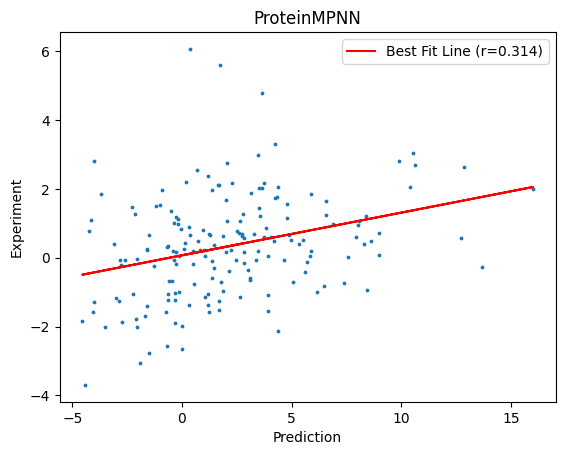

In [25]:
plot_scatter_list(plmpnn_df_ddg['pred'], plmpnn_df_ddg['ener'], "ProteinMPNN", 'Prediction', 'Experiment', midline=False, s=3, trendline=True)

ValueError: Cannot calculate a linear regression if all x values are identical

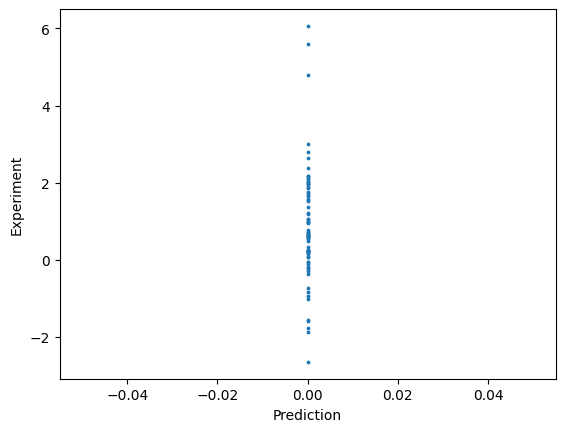

In [26]:
plot_scatter_list(plmpnn_df_ddg_split['pred'], plmpnn_df_ddg_split['ener'], "ProteinMPNN", 'Prediction', 'Experiment', midline=False, s=3, trendline=True)

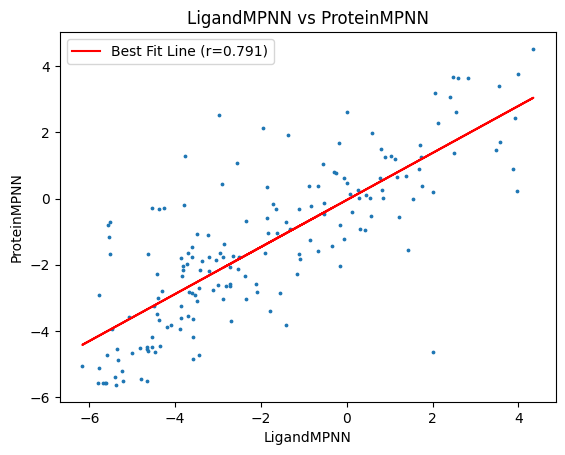

In [13]:
plot_scatter_list(lmpnn_df['pred'], pmpnn_df['pred'], "LigandMPNN vs ProteinMPNN", 'LigandMPNN', 'ProteinMPNN', midline=False, s=3, trendline=True)

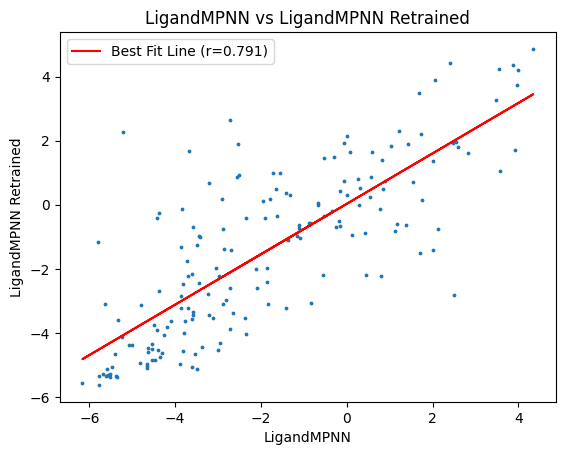

In [16]:
plot_scatter_list(lmpnn_df['pred'], rlmpnn_df['pred'], "LigandMPNN vs LigandMPNN Retrained", 'LigandMPNN', 'LigandMPNN Retrained', midline=False, s=3, trendline=True)

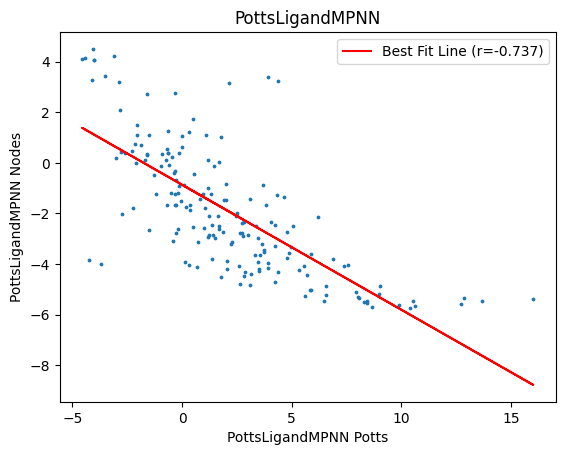

In [15]:
plot_scatter_list(plmpnn_df_ddg['pred'], plmpnn_df_nodes['pred'], "PottsLigandMPNN", 'PottsLigandMPNN Potts', 'PottsLigandMPNN Nodes', midline=False, s=3, trendline=True)

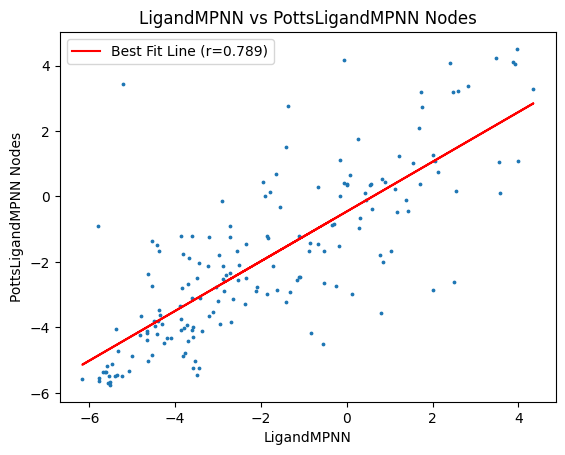

In [17]:
plot_scatter_list(lmpnn_df['pred'], plmpnn_df_nodes['pred'], "LigandMPNN vs PottsLigandMPNN Nodes", 'LigandMPNN', 'PottsLigandMPNN Nodes', midline=False, s=3, trendline=True)

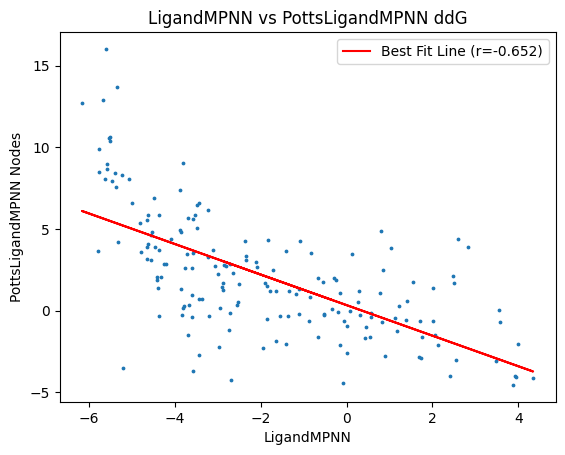

In [21]:
plot_scatter_list(lmpnn_df['pred'], plmpnn_df_ddg['pred'], "LigandMPNN vs PottsLigandMPNN ddG", 'LigandMPNN', 'PottsLigandMPNN Nodes', midline=False, s=3, trendline=True)

In [7]:
pmpnn_df['pred_mean_norm'].corr(pmpnn_df['ener']), pmpnn_df['pred'].corr(pmpnn_df['ener'])

(-0.022572681604691582, -0.17309170680174993)

In [67]:
lmpnn_df['pred_mean_norm'].corr(pmpnn_df['ener']), lmpnn_df['pred'].corr(lmpnn_df['ener'])

(-0.040440248312340756, -0.33324485442752283)

In [70]:
rlmpnn_df['pred_mean_norm'].corr(rlmpnn_df['ener']), rlmpnn_df['pred'].corr(rlmpnn_df['ener'])

(-0.04276175790138452, -0.2906477406903242)

In [77]:
rlmpnn_df['pred_mean_norm'].corr(rlmpnn_df['ener']), rlmpnn_df['pred'].corr(rlmpnn_df['ener'])

(-0.021163057091556244, -0.33180074969106915)

In [79]:
plmpnn_df['pred_mean_norm'].corr(plmpnn_df['ener']), plmpnn_df['pred'].corr(plmpnn_df['ener'])

(0.03145728601877671, 0.31441183909547205)

In [83]:
plmpnn_df['pred_mean_norm'].corr(plmpnn_df['ener']), plmpnn_df['pred'].corr(plmpnn_df['ener'])

(-0.03850133673210761, -0.41337891379998876)

In [28]:
gplmpnn_df['pred_mean_norm'].corr(pmpnn_df['ener']), gplmpnn_df['pred'].corr(pmpnn_df['ener'])

(0.028017640880016893, -0.15882246215190093)

In [32]:
sstats =  pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-dg-prem-stats.csv')
sstats['nlcpl_loss'].mean()

2.714549235269135

In [12]:
sub_df = plmpnn_df[plmpnn_df['pdb'] == '3OXZ']

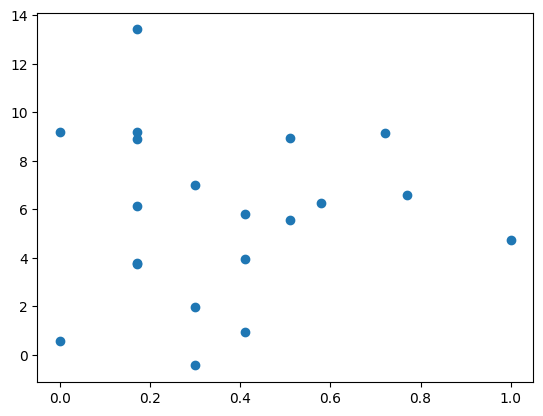

In [16]:
plt.scatter(sub_df['ener'], sub_df['pred'])

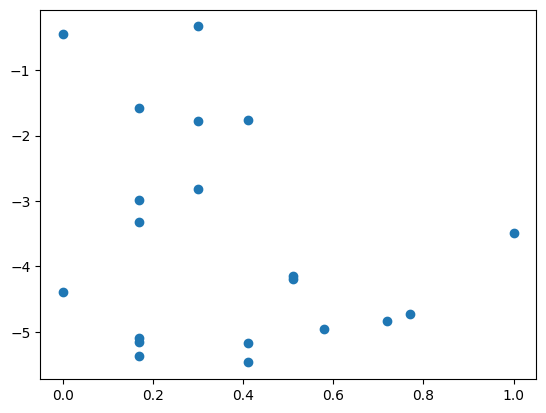

In [33]:
sub_df2 = lmpnn_df[lmpnn_df['pdb'] == '3OXZ']
plt.scatter(sub_df2['ener'], sub_df2['pred'])

In [51]:
fig = px.scatter(lmpnn_df[['pdb', 'pred', 'ener']], x='pred', y='ener',
                 title='Scatterplot of pred vs ener',
                 labels={'pred': 'Predicted Value', 'ener': 'Energy'},
                 hover_data=lmpnn_df[['pdb', 'pred', 'ener']].columns)

# Show the plot
fig.show()

In [52]:
fig = px.scatter(plmpnn_df[['pdb', 'pred', 'ener']], x='pred', y='ener',
                 title='Scatterplot of pred vs ener',
                 labels={'pred': 'Predicted Value', 'ener': 'Energy'},
                 hover_data=plmpnn_df[['pdb', 'pred', 'ener']].columns)

# Show the plot
fig.show()

In [64]:
fig = px.scatter(plmpnn_df[['pdb', 'pred', 'ener']], x='pred', y='ener',
                 title='Scatterplot of pred vs ener',
                 labels={'pred': 'Predicted Value', 'ener': 'Energy'},
                 hover_data=plmpnn_df[['pdb', 'pred', 'ener']].columns)

# Show the plot
fig.show()

In [53]:
plmpnn_df[plmpnn_df['pdb'] == '3CS9']

,pdb,wt,mut,ener,pred,pred_mean_norm
142,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,-0.13,3.906958,-1.476843
143,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITVKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,2.15,5.729763,0.345963
144,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKRGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,0.33,5.196867,-0.186933
145,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKVGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,0.60,1.092427,-4.291374
146,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGEGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,1.48,-1.508454,-6.892254
147,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQFGEVYEGVWKKYSLTVAVKTLKEVEE...,1.27,3.333848,-2.049953
148,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQYGKVYEGVWKKYSLTVAVKTLKEVEE...,2.36,4.734491,-0.649310
149,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQYGVVYEGVWKKYSLTVAVKTLKEVEE...,0.28,1.916801,-3.467000
150,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,0.72,10.243555,4.859754
151,3CS9,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,DKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEVEE...,3.75,8.218491,2.834690


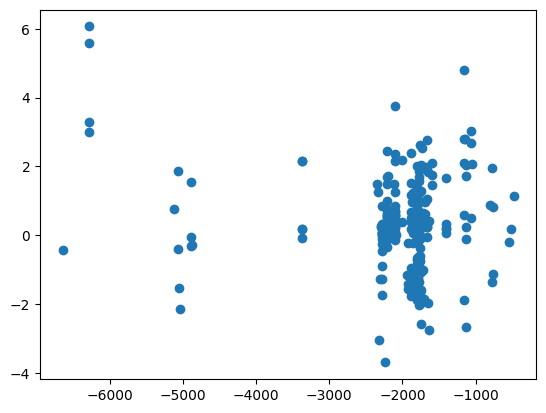

In [44]:
plt.scatter(gplmpnn_df['pred'], gplmpnn_df['ener'])

In [42]:
gplmpnn_df

,pdb,corr,nsr,nlll_loss,nlcpl_loss,n
0,1A4H,-0.748943,0.415888,1.896387,3.210680,7
1,1A9M,NaN,0.510101,1.781356,2.656827,1
2,1AMW,0.139843,0.469484,1.698502,2.997317,7
3,1BV7,NaN,0.459596,1.964982,2.755943,1
4,1BV9,NaN,0.479798,1.940267,2.823938,2
...,...,...,...,...,...,...
97,3OXC,0.630787,0.494949,1.853378,2.487170,6
98,3OXZ,0.016553,0.492537,1.751351,2.800474,20
99,3TKW,0.234517,0.524752,1.742286,2.627072,4
100,3UE4,0.038119,0.429630,1.782264,2.834467,21


In [94]:
ligand_stats_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn/ligand_mpnn-default-prem-stats.csv')
pmpnn_stats_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/protein_mpnn/protein_mpnn-default-prem-stats.csv')
ligand_re_stats_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_retrained/ligand_mpnn_retrained-default-prem-stats_all.csv')
ligand_potts_stats_df = pd.read_csv('/home/fosterb/TERMinator-public_mirror/analysis/mpnn_results/ligand_mpnn_potts/ligand_mpnn_potts-default-prem-stats.csv')


# ligand_df = ligand_df[ligand_df['pdb'] != '3AFK']
# ligand_stats_df = ligand_stats_df[ligand_stats_df['pdb'] != '3AFK']
# pmpnn_df = pmpnn_df[pmpnn_df['pdb'] != '3AFK']
# pmpnn_stats_df = pmpnn_stats_df[pmpnn_stats_df['pdb'] != '3AFK']
# ligand_re_df = ligand_re_df[ligand_re_df['pdb'] != '3AFK']
# ligand_re_stats_df = ligand_re_stats_df[ligand_re_stats_df['pdb'] != '3AFK']


In [79]:
ligand_df['ener'].corr(ligand_df['pred']), ligand_df['ener'].corr(ligand_df['pred_mean_norm'])

(0.09504595680074038, -0.041237058068111045)

In [14]:
ligand_re_df['ener'].corr(ligand_re_df['pred']), ligand_re_df['ener'].corr(ligand_re_df['pred_mean_norm'])

(-0.013789166764059963, -0.13991993551194037)

In [80]:
pmpnn_df['ener'].corr(pmpnn_df['pred']), pmpnn_df['ener'].corr(pmpnn_df['pred_mean_norm'])

(0.24145480434899388, 0.01643355757098239)

In [28]:
ligand_potts_df['ener'].corr(ligand_potts_df['pred']), ligand_potts_df['ener'].corr(ligand_potts_df['pred_mean_norm'])

(-0.04039391638052047, 0.013726879539372159)

In [24]:
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

def plot_scatter_list(real_list, pred_list, title, xlabel='Real E', ylabel='Predited E', midline=False, s=1, trendline=True):
    real_list = np.array(real_list)
    pred_list = np.array(pred_list)
    remove_inds = (np.isnan(real_list)) | (np.isnan(pred_list))
    real_list = real_list[~remove_inds]
    pred_list = pred_list[~remove_inds]
    plt.scatter(real_list, pred_list, s=s)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Calculate the best-fit line
    if trendline:
        slope, intercept, r_value, p_value, std_err = stats.linregress(real_list, pred_list)
        line = slope * real_list + intercept
        plt.plot(real_list, line, color='red', label=f'Best Fit Line (r={r_value:.3f})')
    
    # Plot midline if needed
    if midline:
        plt.xlim([min([min(real_list), min(pred_list)]), max([max(real_list), max(pred_list)])])
        plt.ylim([min([min(real_list), min(pred_list)]), max([max(real_list), max(pred_list)])])
        midline_points = np.arange(min([min(real_list), min(pred_list)]), max([max(real_list), max(pred_list)]), 0.1)
        plt.plot(midline_points, midline_points, color='black')
    
    if trendline:
        plt.legend()
    plt.title(title)
    
    plt.show()
    plt.close()

In [95]:
np.mean(pmpnn_stats_df['nsr']), np.mean(ligand_stats_df['nsr']), np.mean(ligand_re_stats_df['nsr']), np.mean(ligand_potts_stats_df['nsr'])

(0.4888983756862744,
 0.5570090226470589,
 0.5168602906862745,
 0.49626895656250003)

In [93]:
np.mean(pmpnn_stats_df['nsr']), np.mean(ligand_stats_df['nsr']), np.mean(ligand_re_stats_df['nsr']), np.mean(ligand_potts_stats_df['nsr'])

(0.5150411054054055,
 0.5838045916216218,
 0.5322826759459459,
 0.5359546513888889)

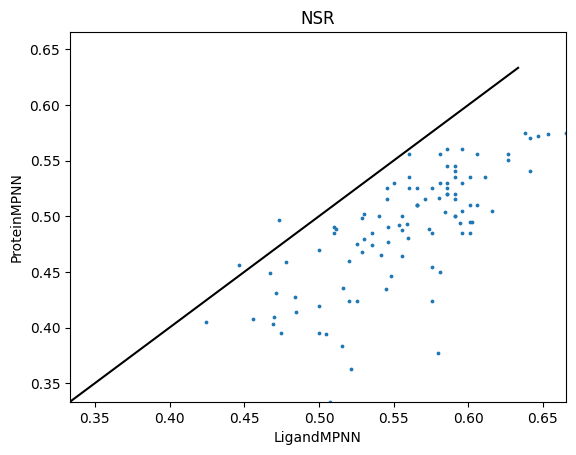

In [86]:
plot_scatter_list(ligand_stats_df['nsr'], pmpnn_stats_df['nsr'], "NSR", 'LigandMPNN', 'ProteinMPNN', midline=True, s=3, trendline=False)

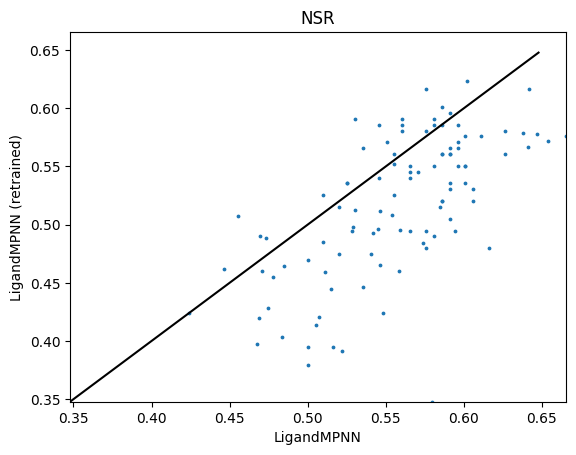

In [87]:
plot_scatter_list(ligand_stats_df['nsr'], ligand_re_stats_df['nsr'], "NSR", 'LigandMPNN', 'LigandMPNN (retrained)', midline=True, s=3, trendline=False)

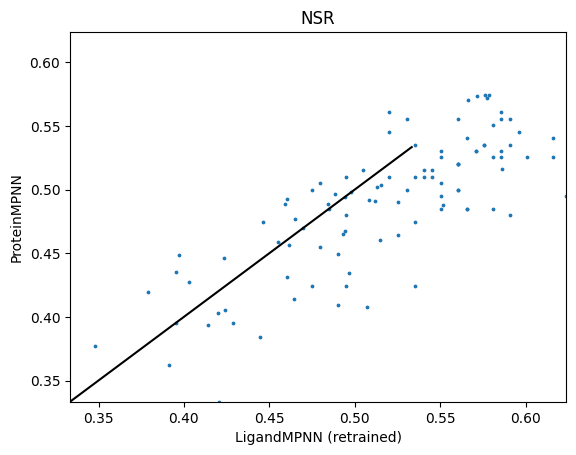

In [88]:
plot_scatter_list(ligand_re_stats_df['nsr'], pmpnn_stats_df['nsr'], "NSR", 'LigandMPNN (retrained)', 'ProteinMPNN', midline=True, s=3, trendline=False)

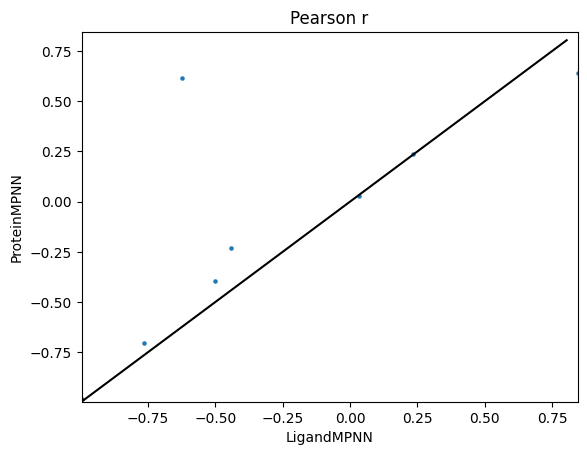

In [42]:
plot_scatter_list(ligand_stats_df['corr'], pmpnn_stats_df['corr'], "Pearson r", 'LigandMPNN', 'ProteinMPNN', midline=True, s=5, trendline=False)

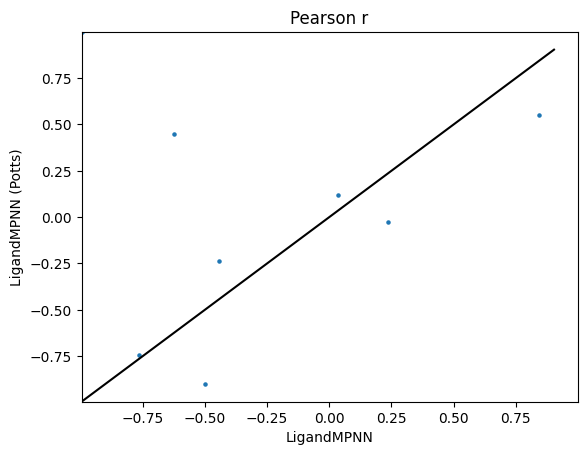

In [43]:
plot_scatter_list(ligand_stats_df['corr'], -1*ligand_potts_stats_df['corr'], "Pearson r", 'LigandMPNN', 'LigandMPNN (Potts)', midline=True, s=5, trendline=False)

In [40]:
ligand_stats_df

,pdb,corr,nsr,nlll_loss,n
0,1A4H,0.034466,0.443925,1.646607,10
1,1DF8,NaN,0.735294,1.039326,1
2,1K3L,NaN,0.609091,1.239008,1
3,1PWM,-0.442919,0.585443,1.323069,8
4,1QY1,NaN,0.554140,1.430188,1
5,1US0,NaN,0.594249,1.312967,1
6,2FGU,NaN,0.527638,1.448114,2
7,2IKI,NaN,0.594855,1.309866,2
8,2PD9,NaN,0.606349,1.312489,1
9,2PDG,-0.501369,0.624204,1.252428,4


In [41]:
ligand_potts_stats_df

,pdb,corr,nsr,nlll_loss,n
0,1A4H,-0.117065,0.453271,1.815007,10
1,1DF8,NaN,0.626050,1.260045,1
2,1K3L,NaN,0.554545,1.518353,1
3,1PWM,0.234506,0.560127,1.372907,8
4,1QY1,NaN,0.464968,1.658952,1
5,1US0,NaN,0.591054,1.323003,1
6,2FGU,NaN,0.557789,1.572539,2
7,2IKI,NaN,0.572347,1.403907,2
8,2PD9,NaN,0.571429,1.385537,1
9,2PDG,0.900474,0.592357,1.333360,4


In [111]:
test_df = pd.read_csv('/mnt/shared/fosterb/protein_ligand_data/Sun_data_ligandmpnn.csv')

new_df = {'WT_name': [], 'mut_type': [], 'ddG_ML': [], 'chain': [], 'chain_list': [], 'sig': [], 'adj_pos': []}

for WT_name, mut_type, ddG_ML, chain, chain_list, sig in zip(test_df['WT_name'], test_df['mut_type'], test_df['ddG_ML'], test_df['chain'], test_df['chain_list'], test_df['sig']):
    new_df['WT_name'].append(WT_name)
    new_df['mut_type'].append(mut_type)
    new_df['ddG_ML'].append(ddG_ML)
    new_df['chain'].append(chain)
    new_df['chain_list'].append(chain_list)
    new_df['sig'].append(sig)
#     if WT_name == '1H7M'
    adj_list = []
    for mt in mut_type.split(';'):
        if WT_name == '1K3L':
            adj_list.append(str(int(mt[1:-1]) - 2))
        elif WT_name not in ['1DF8', '1PWM']:
            adj_list.append(str(int(mt[1:-1]) - 1)) 
        else:
            adj_list.append(mt[1:-1])
    new_df['adj_pos'].append(';'.join(adj_list))

#     else:
#         new_df['adj_pos'].append(adj_pos)
        
        
new_df = pd.DataFrame(new_df)
new_df.to_csv('/mnt/shared/fosterb/protein_ligand_data/Sun_data_ligandmpnn.csv', index=None)

In [20]:
test_df['chain_list'].values[0]

"['A']"

In [22]:
test_df2 = pd.read_csv('/mnt/shared/fosterb/fireprot_data/fireprot_homologue_free_sort.csv')
test_df2['chain_list'].values[0]

"['A']"

In [17]:
test_df

,WT_name,mut_type,ddG_ML,chain,chain_list,sig,adj_pos
0,1CYO,F34H,-3.110000,A,['A'],1CYO_A_F34H,34
1,1CYO,F34L,-1.870000,A,['A'],1CYO_A_F34L,34
2,1CYO,F34Y,0.640000,A,['A'],1CYO_A_F34Y,34
3,1CYO,V44E,-2.380000,A,['A'],1CYO_A_V44E,44
4,1CYO,V44G,-1.900000,A,['A'],1CYO_A_V44G,44
...,...,...,...,...,...,...,...
2538,2AFG,V99L,-0.585000,A,['A'],2AFG_A_V99L,99
2539,2AFG,C107I,0.360000,A,['A'],2AFG_A_C107I,107
2540,2AFG,C107S,-0.602500,A,['A'],2AFG_A_C107S,107
2541,2AFG,C107V,-0.300000,A,['A'],2AFG_A_C107V,107


In [8]:
test_df['adj_pos'].values

array(['34', '34', '34', ..., '107', '107', '122'], dtype=object)

In [47]:
'a'.upper()

'A'

In [51]:
atoms = parsePDB('/mnt/shared/fosterb/S669_data/pdbs/4YEE.pdb', chain='S')

protein_atoms = atoms.select("protein")
backbone = protein_atoms.select("backbone")
other_atoms = atoms.select("not protein and not water")
water_atoms = atoms.select("water")

CA_atoms = protein_atoms.select("name CA")
CA_resnums = CA_atoms.getResnums()
CA_chain_ids = CA_atoms.getChids()
CA_icodes = CA_atoms.getIcodes()

AttributeError: 'NoneType' object has no attribute 'select'

In [34]:
atoms = parsePDB('/mnt/shared/fosterb/bcl2_data/raw_pdb/MCL1_HUMAN_5C6H_A_holo.pdb', chains=['A'])
protein_atoms = atoms.select("protein")
CA_atoms = protein_atoms.select("name CA")
chain_seq = CA_atoms.getResnames()
chain_seq = "".join([restype_3to1[AA] if AA in list(restype_3to1) else "X" for AA in list(chain_seq)])

In [35]:
chain_seq

'EDELYRQSLEIISRYLREQATGAKDTKPMGRSGATSRKALETLRRVGDGVQRNHETAFQGMLRKLDIKNEDDVKSLSRVMIHVFSDGVTNWGRIVTLISFGAFVAKHLKTINQESCIEPLAESITDVLVRTKRDWLVKQRGWDGFVEFFHVEDLEMTQEVGQLLQDMGDDVYQQY'

In [44]:
CA_resnums

array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [57]:
protein_atoms.getResnums()

array([-1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,
        4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,
       10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 17,
       17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19,
       19, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 24, 24,
       24, 25, 25, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26,
       26, 26, 26, 26, 26, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 28, 28,
       28, 28, 29, 29, 29

In [89]:
atoms

<AtomGroup: 1H7M (729 atoms)>

In [90]:
backbone

<Selection: '(backbone) and (protein)' from 1H7M (388 atoms)>

In [97]:
atoms_bb = parsePDB('/mnt/shared/fosterb/fireprot_data/pdbs/1H7M.pdb', selection='pdbter')


@> 729 atoms and 1 coordinate set(s) were parsed in 0.00s.


In [78]:
atoms_bb.select("name CA")

<Selection: 'name CA' from 1H7M (97 atoms)>

In [46]:
test_df[test_df['WT_name'] == '1H7M']

,WT_name,mut_type,ddG_ML,chain,chain_list,sig,adj_pos
123,1H7M,D2A,-0.530,A,['A'],1H7M_A_D2A,3
124,1H7M,E6A,-0.830,A,['A'],1H7M_A_E6A,7
125,1H7M,R8A,-0.760,A,['A'],1H7M_A_R8A,9
126,1H7M,K9A,-0.445,A,['A'],1H7M_A_K9A,10
127,1H7M,K9M,-0.500,A,['A'],1H7M_A_K9M,10
128,1H7M,D12A,0.240,A,['A'],1H7M_A_D12A,13
129,1H7M,K15A,-0.910,A,['A'],1H7M_A_K15A,16
130,1H7M,R21A,0.070,A,['A'],1H7M_A_R21A,22
131,1H7M,K22A,0.430,A,['A'],1H7M_A_K22A,23
132,1H7M,K28A,-1.190,A,['A'],1H7M_A_K28A,29


In [50]:
raw_data_dir

'/mnt/shared/fosterb/fireprot_data/pdbs'

In [17]:
test_df

,pos,wildtype,mutant,mut_type,chain,ddG_ML,WT_name,chain_list,adj_pos,sig
0,140;141;143;145;146;147;150;151;152;154;155;15...,P;M;A;K;Q;A;E;A;G;E;F;E;L;R,A;A;D;G;A;Q;R;M;A;D;Y;N;A;Q,P140A;M141A;A143D;K145G;Q146A;A147Q;E150R;A151...,B,-11.742132,B2CL1_HUMAN_4CIN_A_holo,"[A, B]",0;1;3;5;6;7;10;11;12;14;15;16;17;18,B2CL1_HUMAN_4CIN_A_holo_B_P140A;M141A;A143D;K1...
1,140;141;143;145;146;147;150;151;152;154;155;15...,P;M;A;K;Q;A;E;A;G;E;F;E;L;R,A;A;H;G;A;Q;R;M;A;D;V;Q;A;Q,P140A;M141A;A143H;K145G;Q146A;A147Q;E150R;A151...,B,-11.081939,B2CL1_HUMAN_4CIN_A_holo,"[A, B]",0;1;3;5;6;7;10;11;12;14;15;16;17;18,B2CL1_HUMAN_4CIN_A_holo_B_P140A;M141A;A143H;K1...
2,140;141;143;144;145;146;147;149;150;151;152;15...,P;M;A;V;K;Q;A;R;E;A;G;E;F;L;R,A;A;Q;I;V;A;Q;I;R;M;A;D;V;A;Q,P140A;M141A;A143Q;V144I;K145V;Q146A;A147Q;R149...,B,-9.537042,B2CL1_HUMAN_4CIN_A_holo,"[A, B]",0;1;3;4;5;6;7;9;10;11;12;14;15;17;18,B2CL1_HUMAN_4CIN_A_holo_B_P140A;M141A;A143Q;V1...
3,140;141;142;143;145;146;147;149;150;151;152;15...,P;M;A;A;K;Q;A;R;E;A;G;E;F;E;L;R,A;A;C;D;I;A;Q;K;R;M;A;D;L;H;A;Q,P140A;M141A;A142C;A143D;K145I;Q146A;A147Q;R149...,B,-9.713138,B2CL1_HUMAN_4CIN_A_holo,"[A, B]",0;1;2;3;5;6;7;9;10;11;12;14;15;16;17;18,B2CL1_HUMAN_4CIN_A_holo_B_P140A;M141A;A142C;A1...
4,140;141;142;143;145;146;147;149;150;151;152;15...,P;M;A;A;K;Q;A;R;E;A;G;E;F;E;L;R,A;A;C;E;S;A;Q;I;R;M;A;D;V;N;A;Q,P140A;M141A;A142C;A143E;K145S;Q146A;A147Q;R149...,B,-9.564128,B2CL1_HUMAN_4CIN_A_holo,"[A, B]",0;1;2;3;5;6;7;9;10;11;12;14;15;16;17;18,B2CL1_HUMAN_4CIN_A_holo_B_P140A;M141A;A142C;A1...
...,...,...,...,...,...,...,...,...,...,...
205381,155;156;157;158;160;162;164;165;166;169;170;17...,M;T;Q;E;G;L;Q;D;M;D;V;Y;Q;Q,W;E;V;Q;S;E;A;R;I;E;I;D;A;Y,M155W;T156E;Q157V;E158Q;G160S;L162E;Q164A;D165...,B,-12.979535,MCL1_HUMAN_5C6H_I_holo,"[A, B]",0;1;2;3;5;7;9;10;11;14;15;16;17;18,MCL1_HUMAN_5C6H_I_holo_B_M155W;T156E;Q157V;E15...
205382,155;156;157;158;160;162;164;165;166;169;171;17...,M;T;Q;E;G;L;Q;D;M;D;Y;Q;Q,W;E;V;Q;S;E;A;R;I;E;E;A;Y,M155W;T156E;Q157V;E158Q;G160S;L162E;Q164A;D165...,B,-13.098209,MCL1_HUMAN_5C6H_I_holo,"[A, B]",0;1;2;3;5;7;9;10;11;14;16;17;18,MCL1_HUMAN_5C6H_I_holo_B_M155W;T156E;Q157V;E15...
205383,155;156;157;158;160;162;164;165;166;169;170;17...,M;T;Q;E;G;L;Q;D;M;D;V;Y;Q;Q,W;E;V;Q;S;E;T;R;I;E;L;D;A;Y,M155W;T156E;Q157V;E158Q;G160S;L162E;Q164T;D165...,B,-12.938338,MCL1_HUMAN_5C6H_I_holo,"[A, B]",0;1;2;3;5;7;9;10;11;14;15;16;17;18,MCL1_HUMAN_5C6H_I_holo_B_M155W;T156E;Q157V;E15...
205384,155;156;157;159;160;162;164;165;166;169;170;17...,M;T;Q;V;G;L;Q;D;M;D;V;Y;Q;Q,W;E;Y;I;V;E;I;R;I;E;I;D;A;Y,M155W;T156E;Q157Y;V159I;G160V;L162E;Q164I;D165...,B,-13.401835,MCL1_HUMAN_5C6H_I_holo,"[A, B]",0;1;2;4;5;7;9;10;11;14;15;16;17;18,MCL1_HUMAN_5C6H_I_holo_B_M155W;T156E;Q157Y;V15...


In [10]:
all_refs

[]

In [7]:
output_dict

{'S': tensor([[ 2, 12, 14,  3,  3, 13,  9, 17,  6,  9, 17, 12,  5,  0, 14, 17, 17, 14,
           5, 12,  2, 18, 16,  6,  5,  2, 17, 11,  5, 11, 12, 12,  5, 16,  5, 16,
          17, 16, 16,  3,  7,  8,  2,  5, 18, 17,  5, 17, 16, 18,  2, 15,  5,  5,
          15,  0, 15,  4,  8, 17,  5,  8,  2,  5,  8, 19,  3,  9, 14,  9,  0, 12]],
        device='cuda:0'),
 'sampling_probs': tensor([[[7.4831e-13, 6.7997e-20, 1.0000e+00,  ..., 3.6304e-15,
           1.2478e-21, 3.5563e-20],
          [4.6059e-05, 3.1482e-19, 3.6798e-13,  ..., 8.2348e-13,
           1.5516e-12, 4.9201e-15],
          [2.9572e-14, 2.4548e-20, 6.9150e-19,  ..., 2.8500e-03,
           4.9544e-11, 2.5836e-16],
          ...,
          [8.4095e-25, 8.7943e-25, 4.4087e-25,  ..., 7.5053e-25,
           1.3131e-24, 2.2236e-25],
          [1.0000e+00, 1.0186e-23, 3.6296e-19,  ..., 1.4956e-24,
           5.4664e-24, 7.0555e-24],
          [4.3810e-06, 4.1022e-20, 1.4901e-05,  ..., 6.1119e-17,
           1.1894e-20, 8.6563e-19]]]

In [18]:
feature_dict['S']

tensor([[11,  9, 19,  4, 13,  5,  9,  8, 19, 10, 17, 12,  5,  0, 14, 17, 16, 14,
          5,  9,  2, 18,  8, 18, 14,  2, 13,  2,  5, 15, 12, 13,  5,  3,  5, 16,
         17, 16,  5,  3,  9,  6, 11,  5, 18,  7,  2, 17, 16, 18,  2,  0,  5,  5,
         15, 11, 15, 19, 14, 10,  5,  0,  3,  5,  8,  4,  2,  9,  8,  9,  0, 12]],
       device='cuda:0', dtype=torch.int32)

In [8]:
output_dict

{'S': tensor([[11,  9, 19,  4, 13,  5,  9,  8, 19, 10, 17, 12,  5,  0, 14, 17, 16, 14,
           5,  9,  2, 18,  8, 18, 14,  2, 13,  2,  5, 15, 12, 13,  5,  3,  5, 16,
          17, 16,  5,  3,  9,  6, 11,  5, 18,  7,  2, 17, 16, 18,  2,  0,  5,  5,
          15, 11, 15, 19, 14, 10,  5,  0,  3,  5,  8,  4,  2,  9,  8,  9,  0, 12]],
        device='cuda:0'),
 'sampling_probs': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 'log_probs': tensor([[[-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          ...,
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.]]], device='cuda:0')